# 04 Exploratory Data Analysis

Exploração da distribuição do target, valores ausentes e correlações entre variáveis.

## Abordagem

Aqui exploramos o dataset gerado em `data/processed`, verificamos a distribuição do target e identificamos padrões de missing e correlação antes de avançar para a modelagem.


In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_store = pd.read_parquet(Path('..') / 'data' / 'processed' / 'feature_store.parquet')
target_population = pd.read_parquet(Path('..') / 'data' / 'processed' / 'population_target.parquet')
dataset = feature_store.merge(target_population[['id_contrato', 'target']], on='id_contrato', how='left')
dataset['target'] = dataset['target'].fillna(0).astype(int)
print('Dataset shape:', dataset.shape)
dataset[['target']].describe()

Dataset shape: (186890, 52)


,target
count,186890.000000
mean,0.005602
std,0.074638
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [2]:
print('Target distribution:')
print(dataset['target'].value_counts(normalize=True))

missing = dataset.isna().mean().sort_values(ascending=False).head(20)
display(missing)

Target distribution:
target
0    0.994398
1    0.005602
Name: proportion, dtype: float64


taxa_juros_padrao                0.996640
taxa_juros_promocional           0.996640
customer_interest_rate_mean      0.983081
valor_entrada                    0.535973
flag_seguro_contratado           0.402370
ocupacao                         0.328621
valor_bem                        0.232420
valor_parcela                    0.223468
installment_to_monthly_income    0.223468
qtd_parcelas_planejadas          0.223463
customer_parcel_count            0.002231
customer_parcel_mean             0.000401
tipo_produto                     0.000000
finalidade_emprestimo            0.000000
dia_semana_solicitacao           0.000000
id_contrato                      0.000000
valor_credito                    0.000000
tipo_contrato                    0.000000
id_cliente                       0.000000
percentual_entrada               0.000000
dtype: float64

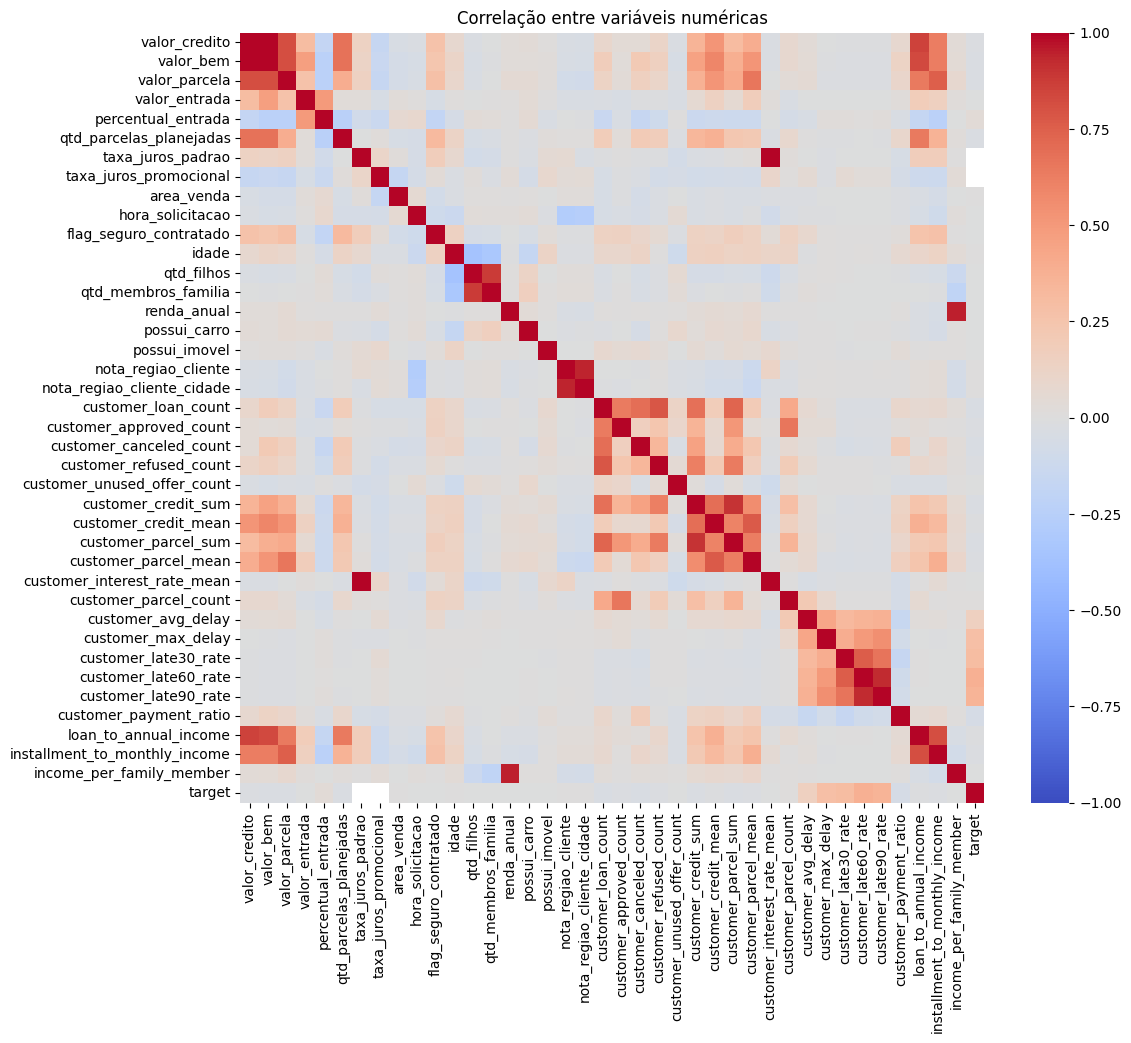

In [3]:
numeric = dataset.select_dtypes(include=['number']).drop(columns=['id_contrato','id_cliente'])
corr = numeric.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlação entre variáveis numéricas')
plt.show()

## Observações iniciais

- A target escolhida (`ever_60`) é rara, com cerca de 1% da população Approved.
- O conjunto de features tem baixa taxa de valores ausentes após agregação histórica.
- A correlação inicial ajuda a priorizar variáveis de alavancagem e atraso de pagamento para a modelagem.